In [1]:
import wandb
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np

c:\Users\maart\Documents\Studie\Vakken\Thesis\Code\Experiments\env\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
c:\Users\maart\Documents\Studie\Vakken\Thesis\Code\Experiments\env\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or

In [2]:
api = wandb.Api()
entity, project= "maarten1499", "robustRL_benchmark"
runs = api.runs(entity + "/" + project, order="created_at")
runs = runs[:56]
for run in runs:
    print(run.displayName)

helpful-snowball-445
vivid-wind-444
light-microwave-434
bumbling-dew-442
astral-wildflower-441
noble-darkness-440
lucky-voice-437
polar-frost-434
still-frog-432
elated-galaxy-429
colorful-snowflake-438
wandering-sunset-432
easy-snow-442
misunderstood-terrain-445
wandering-water-429
cerulean-fire-439
vocal-resonance-436
drawn-mountain-418
good-cosmos-421
driven-totem-419
devout-flower-421
woven-gorge-421
radiant-bush-425
lively-glade-426
eager-forest-426
dauntless-sunset-417
atomic-bush-425
summer-snow-416
twilight-water-419
super-planet-429
gentle-dew-421
morning-bird-414
valiant-frost-410
polar-salad-411
mild-field-407
gallant-oath-412
serene-planet-414
earthy-field-409
peach-bee-408
true-durian-413
daily-sunset-401
fiery-dust-396
valiant-fog-392
scarlet-glitter-394
effortless-firebrand-399
fine-dragon-400
visionary-sun-404
honest-sponge-395
genial-sun-406
chocolate-fire-396
ruby-fog-402
glorious-blaze-405
solar-energy-395
pretty-resonance-393
silver-hill-403
rare-frost-391


In [3]:
def process_run(run):


    run_stats = {}
    run_stats["display_name"] = run.displayName

    config = ast.literal_eval(run.config)
    run_stats["agent_type"] = config["agent_type"]["value"]
    run_stats["env"] = config["env"]["value"]
    run_stats["noise_factor"] = config["noise_factor"]["value"]
    run_stats["noise_sigma"] = config["noise_sigma"]["value"]

    history = run.history()

    run_stats["height_failure_count"] = history["Height failure"].dropna().sum()
    run_stats["angle_failure_count"] = history["Angle failure"].dropna().sum()
    
    run_stats["mean_cumulative_reward"] = history["Cumulative reward"].dropna().mean()
    run_stats["mean_distance"] = history["Distance"].dropna().mean()

    return run_stats    

In [4]:
run_stats = []
for run in runs:
    run_stats.append(process_run(run))


In [5]:
df = pd.DataFrame(run_stats)
df_hopper = df[df["env"] == "Hopper-v5"]
df_walker = df[df["env"] == "Walker2d-v5"]

How well do agents perform on each environment without noise?

In [6]:
def plot_graph(groups, data):
    x = np.arange(4)
    width=0.25
    multiplier = 0

    fig, ax = plt.subplots(layout='constrained')

    for attribute, measurement in data.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Mean Distance')
    ax.set_title('Mean Distance with no noise')
    ax.set_xticks(x + width, groups)
    ax.legend(loc='upper left', ncols=4)
    ax.set_ylim(0, 15)

    plt.show()

In [10]:
df_hopper_no_noise = df_hopper[df_hopper["noise_factor"] == "base"]
df_walker_no_noise = df_walker[df_walker["noise_factor"] == "base"]
agent_types = df_hopper_no_noise["agent_type"]

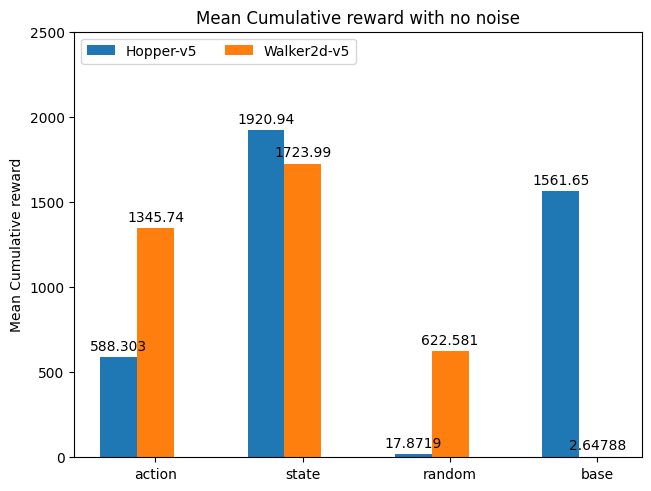

In [ ]:
return_data = {
    "Hopper-v5" : df_hopper_no_noise["mean_cumulative_reward"],
    "Walker2d-v5": df_walker_no_noise["mean_cumulative_reward"]
}

plot_graph(agent_types, return_data)

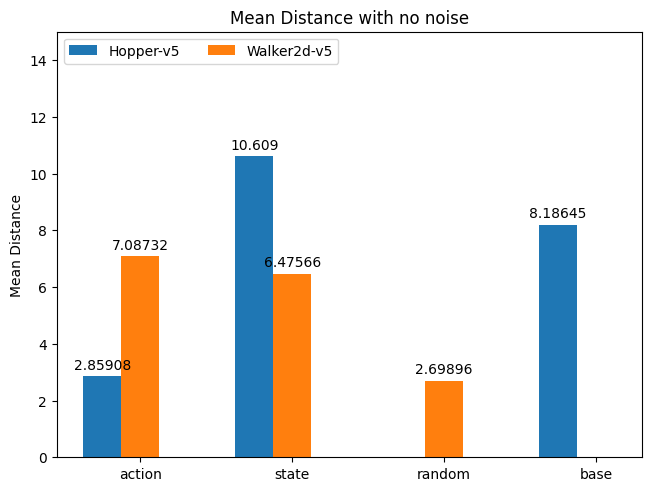

In [11]:
distance_data = {
    "Hopper-v5" : df_hopper_no_noise["mean_distance"],
    "Walker2d-v5": df_walker_no_noise["mean_distance"]}

plot_graph(agent_types, distance_data)

How well does each agent do on each task with noise?

In [27]:
print(df_hopper)

                 display_name agent_type        env noise_factor  noise_sigma  \
4       astral-wildflower-441     action  Hopper-v5        state         0.10   
5          noble-darkness-440     random  Hopper-v5        state         0.01   
6             lucky-voice-437       base  Hopper-v5       action         0.10   
8              still-frog-432     random  Hopper-v5        state         0.05   
13  misunderstood-terrain-445      state  Hopper-v5       action         0.10   
14        wandering-water-429       base  Hopper-v5        state         0.01   
16        vocal-resonance-436       base  Hopper-v5        state         0.05   
18            good-cosmos-421       base  Hopper-v5        state         0.10   
19           driven-totem-419     action  Hopper-v5       action         0.01   
20          devout-flower-421     random  Hopper-v5        state         0.10   
25       dauntless-sunset-417     random  Hopper-v5       action         0.10   
29           super-planet-42

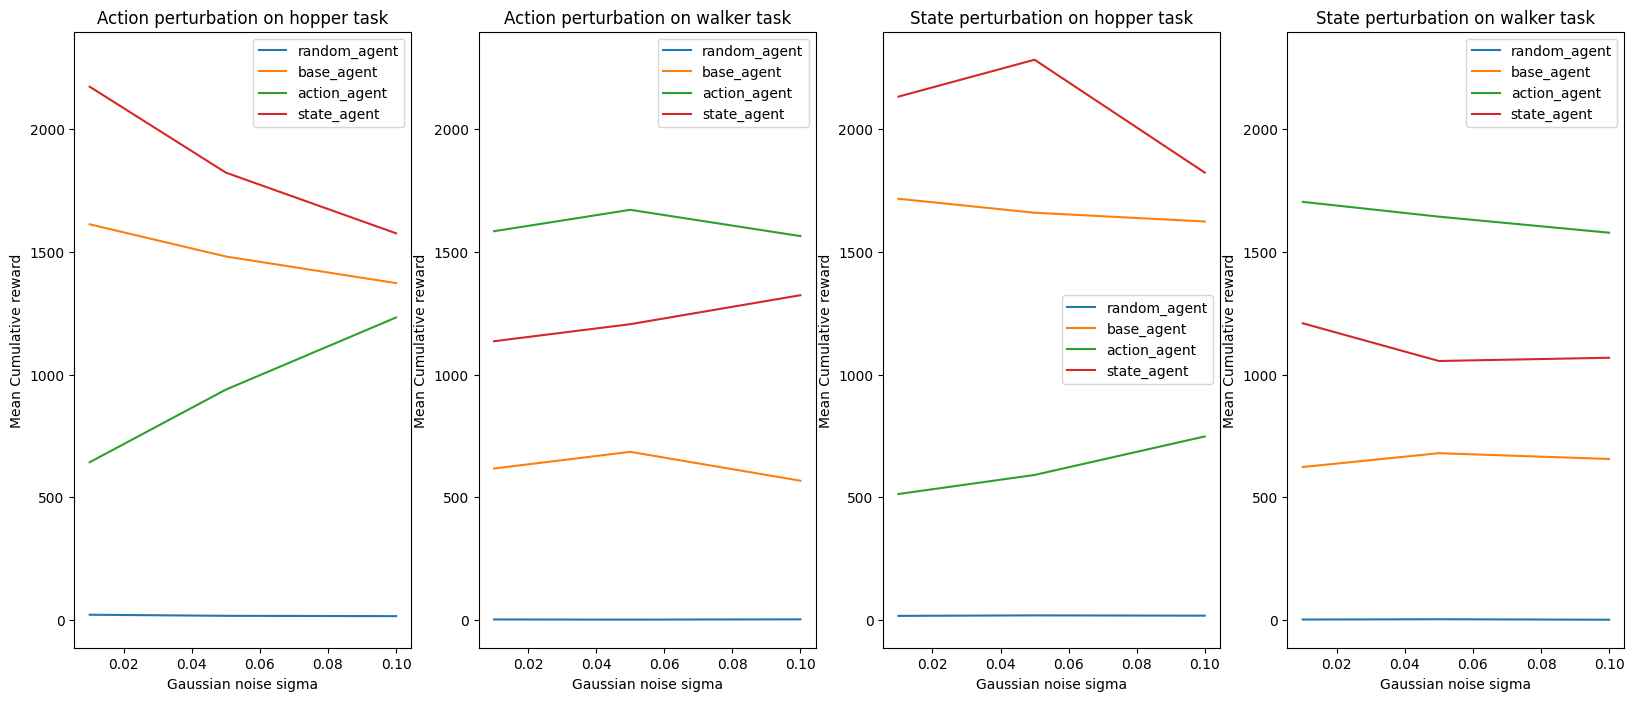

In [19]:

# Dfs for action perturbed agents on hopper task
df_hopper_random_action = df_hopper[(df_hopper["noise_factor"]=="action") & (df_hopper["agent_type"]=="random")].sort_values(by=["noise_sigma"])
df_hopper_base_action = df_hopper[(df_hopper["noise_factor"]=="action") & (df_hopper["agent_type"]=="base")].sort_values(by=["noise_sigma"])
df_hopper_action_action = df_hopper[(df_hopper["noise_factor"]=="action") & (df_hopper["agent_type"]=="action")].sort_values(by=["noise_sigma"])
df_hopper_state_action = df_hopper[(df_hopper["noise_factor"]=="action") & (df_hopper["agent_type"]=="state")].sort_values(by=["noise_sigma"])

# Dfs for state perturbed agents on hopper task
df_hopper_random_state = df_hopper[(df_hopper["noise_factor"]=="state") & (df_hopper["agent_type"]=="random")].sort_values(by=["noise_sigma"])
df_hopper_base_state = df_hopper[(df_hopper["noise_factor"]=="state") & (df_hopper["agent_type"]=="base")].sort_values(by=["noise_sigma"])
df_hopper_action_state = df_hopper[(df_hopper["noise_factor"]=="state") & (df_hopper["agent_type"]=="action")].sort_values(by=["noise_sigma"])
df_hopper_state_state = df_hopper[(df_hopper["noise_factor"]=="state") & (df_hopper["agent_type"]=="state")].sort_values(by=["noise_sigma"])


# Dfs for action perturbed agents on walker task
df_walker_random_action = df_walker[(df_walker["noise_factor"]=="action") & (df_walker["agent_type"]=="random")].sort_values(by=["noise_sigma"])
df_walker_base_action = df_walker[(df_walker["noise_factor"]=="action") & (df_walker["agent_type"]=="base")].sort_values(by=["noise_sigma"])
df_walker_action_action = df_walker[(df_walker["noise_factor"]=="action") & (df_walker["agent_type"]=="action")].sort_values(by=["noise_sigma"])
df_walker_state_action = df_walker[(df_walker["noise_factor"]=="action") & (df_walker["agent_type"]=="state")].sort_values(by=["noise_sigma"])

# Dfs for state perturbed agents on walker task
df_walker_random_state = df_walker[(df_walker["noise_factor"]=="state") & (df_walker["agent_type"]=="random")].sort_values(by=["noise_sigma"])
df_walker_base_state = df_walker[(df_walker["noise_factor"]=="state") & (df_walker["agent_type"]=="base")].sort_values(by=["noise_sigma"])
df_walker_action_state = df_walker[(df_walker["noise_factor"]=="state") & (df_walker["agent_type"]=="action")].sort_values(by=["noise_sigma"])
df_walker_state_state = df_walker[(df_walker["noise_factor"]=="state") & (df_walker["agent_type"]=="state")].sort_values(by=["noise_sigma"])

x_axis = [0.01, 0.05, 0.10]

plt.figure(figsize=(20,8))
ax1 = plt.subplot(141)
plt.title("Action perturbation on hopper task")
ax1.set_xlabel("Gaussian noise sigma")
ax1.set_ylabel("Mean Cumulative reward")
plt.plot(x_axis, df_hopper_random_action["mean_cumulative_reward"], label="random_agent")
plt.plot(x_axis, df_hopper_base_action["mean_cumulative_reward"], label="base_agent")
plt.plot(x_axis, df_hopper_action_action["mean_cumulative_reward"], label="action_agent")
plt.plot(x_axis, df_hopper_state_action["mean_cumulative_reward"], label="state_agent")
plt.legend()

ax2 = plt.subplot(142, sharex=ax1, sharey=ax1)
plt.title("Action perturbation on walker task")
ax2.set_xlabel("Gaussian noise sigma")
ax2.set_ylabel("Mean Cumulative reward")
plt.plot(x_axis, df_walker_random_action["mean_cumulative_reward"], label="random_agent")
plt.plot(x_axis, df_walker_base_action["mean_cumulative_reward"], label="base_agent")
plt.plot(x_axis, df_walker_action_action["mean_cumulative_reward"], label="action_agent")
plt.plot(x_axis, df_walker_state_action["mean_cumulative_reward"], label="state_agent")
plt.legend()

ax3 = plt.subplot(143, sharex=ax1, sharey=ax1)
plt.title("State perturbation on hopper task")
ax3.set_xlabel("Gaussian noise sigma")
ax3.set_ylabel("Mean Cumulative reward")
plt.plot(x_axis, df_hopper_random_state["mean_cumulative_reward"], label="random_agent")
plt.plot(x_axis, df_hopper_base_state["mean_cumulative_reward"], label="base_agent")
plt.plot(x_axis, df_hopper_action_state["mean_cumulative_reward"], label="action_agent")
plt.plot(x_axis, df_hopper_state_state["mean_cumulative_reward"], label="state_agent")
plt.legend()

ax4 = plt.subplot(144, sharex=ax1, sharey=ax1)
plt.title("State perturbation on walker task")
ax4.set_xlabel("Gaussian noise sigma")
ax4.set_ylabel("Mean Cumulative reward")
plt.plot(x_axis, df_walker_random_state["mean_cumulative_reward"], label="random_agent")
plt.plot(x_axis, df_walker_base_state["mean_cumulative_reward"], label="base_agent")
plt.plot(x_axis, df_walker_action_state["mean_cumulative_reward"], label="action_agent")
plt.plot(x_axis, df_walker_state_state["mean_cumulative_reward"], label="state_agent")
plt.legend()

plt.show()

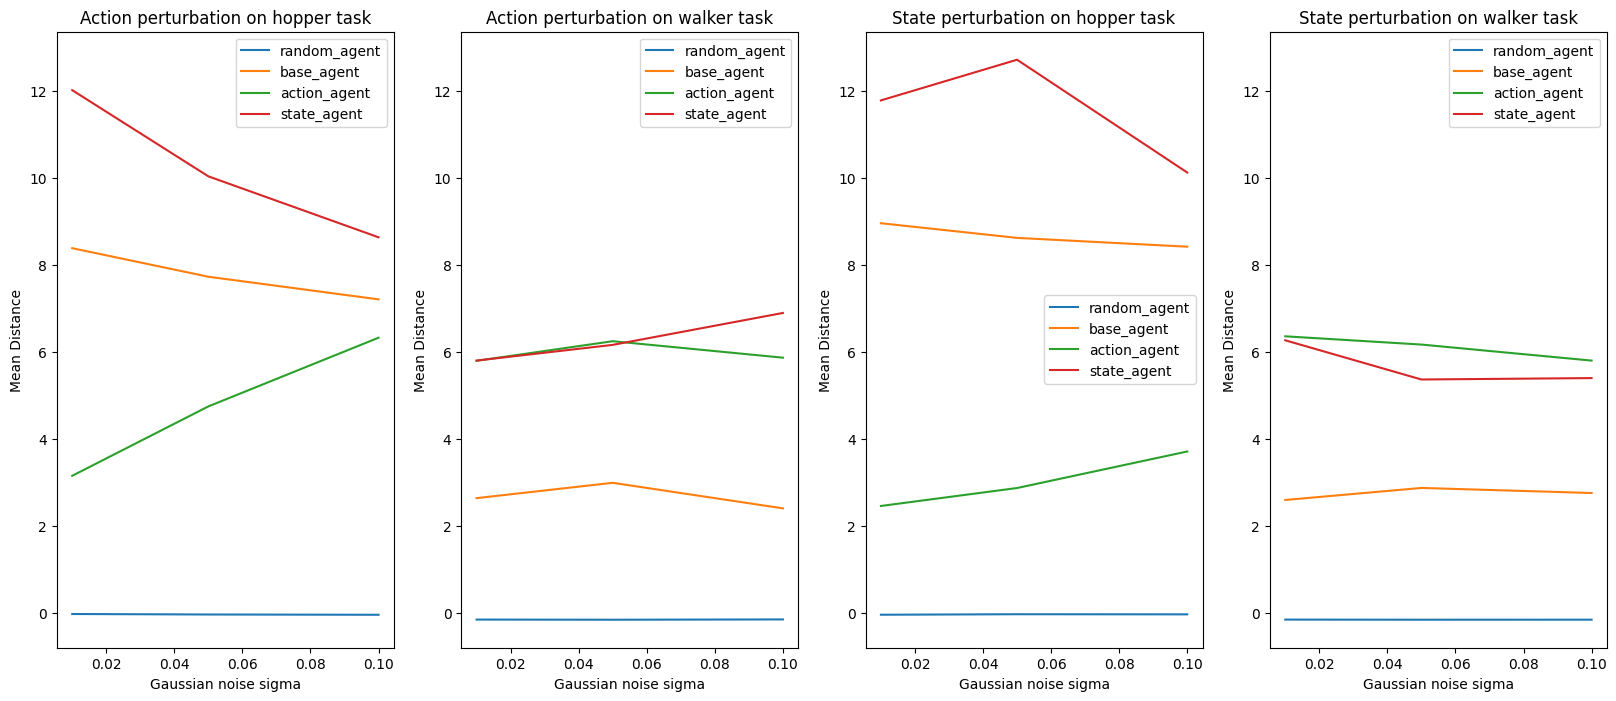

In [18]:
# Dfs for action perturbed agents on hopper task
df_hopper_random_action = df_hopper[(df_hopper["noise_factor"]=="action") & (df_hopper["agent_type"]=="random")].sort_values(by=["noise_sigma"])
df_hopper_base_action = df_hopper[(df_hopper["noise_factor"]=="action") & (df_hopper["agent_type"]=="base")].sort_values(by=["noise_sigma"])
df_hopper_action_action = df_hopper[(df_hopper["noise_factor"]=="action") & (df_hopper["agent_type"]=="action")].sort_values(by=["noise_sigma"])
df_hopper_state_action = df_hopper[(df_hopper["noise_factor"]=="action") & (df_hopper["agent_type"]=="state")].sort_values(by=["noise_sigma"])

# Dfs for state perturbed agents on hopper task
df_hopper_random_state = df_hopper[(df_hopper["noise_factor"]=="state") & (df_hopper["agent_type"]=="random")].sort_values(by=["noise_sigma"])
df_hopper_base_state = df_hopper[(df_hopper["noise_factor"]=="state") & (df_hopper["agent_type"]=="base")].sort_values(by=["noise_sigma"])
df_hopper_action_state = df_hopper[(df_hopper["noise_factor"]=="state") & (df_hopper["agent_type"]=="action")].sort_values(by=["noise_sigma"])
df_hopper_state_state = df_hopper[(df_hopper["noise_factor"]=="state") & (df_hopper["agent_type"]=="state")].sort_values(by=["noise_sigma"])


# Dfs for action perturbed agents on walker task
df_walker_random_action = df_walker[(df_walker["noise_factor"]=="action") & (df_walker["agent_type"]=="random")].sort_values(by=["noise_sigma"])
df_walker_base_action = df_walker[(df_walker["noise_factor"]=="action") & (df_walker["agent_type"]=="base")].sort_values(by=["noise_sigma"])
df_walker_action_action = df_walker[(df_walker["noise_factor"]=="action") & (df_walker["agent_type"]=="action")].sort_values(by=["noise_sigma"])
df_walker_state_action = df_walker[(df_walker["noise_factor"]=="action") & (df_walker["agent_type"]=="state")].sort_values(by=["noise_sigma"])

# Dfs for state perturbed agents on walker task
df_walker_random_state = df_walker[(df_walker["noise_factor"]=="state") & (df_walker["agent_type"]=="random")].sort_values(by=["noise_sigma"])
df_walker_base_state = df_walker[(df_walker["noise_factor"]=="state") & (df_walker["agent_type"]=="base")].sort_values(by=["noise_sigma"])
df_walker_action_state = df_walker[(df_walker["noise_factor"]=="state") & (df_walker["agent_type"]=="action")].sort_values(by=["noise_sigma"])
df_walker_state_state = df_walker[(df_walker["noise_factor"]=="state") & (df_walker["agent_type"]=="state")].sort_values(by=["noise_sigma"])

x_axis = [0.01, 0.05, 0.10]

plt.figure(figsize=(20,8))
ax1 = plt.subplot(141)
plt.title("Action perturbation on hopper task")
ax1.set_xlabel("Gaussian noise sigma")
ax1.set_ylabel("Mean Distance")
plt.plot(x_axis, df_hopper_random_action["mean_distance"], label="random_agent")
plt.plot(x_axis, df_hopper_base_action["mean_distance"], label="base_agent")
plt.plot(x_axis, df_hopper_action_action["mean_distance"], label="action_agent")
plt.plot(x_axis, df_hopper_state_action["mean_distance"], label="state_agent")
plt.legend()

ax2 = plt.subplot(142, sharex=ax1, sharey=ax1)
plt.title("Action perturbation on walker task")
ax2.set_xlabel("Gaussian noise sigma")
ax2.set_ylabel("Mean Distance")
plt.plot(x_axis, df_walker_random_action["mean_distance"], label="random_agent")
plt.plot(x_axis, df_walker_base_action["mean_distance"], label="base_agent")
plt.plot(x_axis, df_walker_action_action["mean_distance"], label="action_agent")
plt.plot(x_axis, df_walker_state_action["mean_distance"], label="state_agent")
plt.legend()

ax3 = plt.subplot(143, sharex=ax1, sharey=ax1)
plt.title("State perturbation on hopper task")
ax3.set_xlabel("Gaussian noise sigma")
ax3.set_ylabel("Mean Distance")
plt.plot(x_axis, df_hopper_random_state["mean_distance"], label="random_agent")
plt.plot(x_axis, df_hopper_base_state["mean_distance"], label="base_agent")
plt.plot(x_axis, df_hopper_action_state["mean_distance"], label="action_agent")
plt.plot(x_axis, df_hopper_state_state["mean_distance"], label="state_agent")
plt.legend()

ax4 = plt.subplot(144, sharex=ax1, sharey=ax1)
plt.title("State perturbation on walker task")
ax4.set_xlabel("Gaussian noise sigma")
ax4.set_ylabel("Mean Distance")
plt.plot(x_axis, df_walker_random_state["mean_distance"], label="random_agent")
plt.plot(x_axis, df_walker_base_state["mean_distance"], label="base_agent")
plt.plot(x_axis, df_walker_action_state["mean_distance"], label="action_agent")
plt.plot(x_axis, df_walker_state_state["mean_distance"], label="state_agent")
plt.legend()

plt.show()